# <font color='blue'>FUMEC - Analytics com Python</font>
## **Lista de exercícios 09 - Introdução à Regressão**

<br>**ATENÇÃO:** para salvar o arquivo .ipynb do notebook, faça da seguinte forma:

* **Google Colaboratory**: opção do menu "Arquivo --> Fazer download --> Baixar o .ipynb"

* Salve o arquivo com o nome "**SeuNome_lista09.ipynb**"

<br>



### **Importar o arquivo de dados**:

Importar o arquivo de dados "**dados_portuarios.csv**" para o Google Colab.



In [ ]:
import pandas as pd
import numpy as np  #biblioteca necessária para trabalhar com os vetores e matrizes
import matplotlib.pyplot as plt #biblioteca utilizada para construir os gráficos

### **01) Carregar e preparar o dataset para a regressão**:

Explorar o dataset "**dados_portuarios.csv**" utilizando os recursos da biblioteca Pandas.



In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1zJhnnDm1qd8qeCPCSN-rpWlwlqS0Zc7I')
df.head()

,valid_import,item,importer_id,exporter_id,country_of_origin,declared_quantity,declared_cost,mode_of_transport,route,date_of_departure,date_of_arrival,declared_weight,actual_weight,days_in_transit
0,True,cigar,111,222,India,129,3784.402551,sea,asia,04/25/2019,05/13/2019,1608.605135,31637.661221,18.232857
1,True,cigar,111,222,India,104,3081.350806,sea,america,04/22/2019,05/24/2019,831.719301,848.273419,32.436029
2,True,cigar,111,222,India,130,4414.125741,sea,europe,04/29/2019,05/16/2019,1527.704165,1582.063911,16.996206
3,True,cigar,111,222,India,143,2533.535991,sea,panama,05/05/2019,05/25/2019,1138.680563,1179.993817,19.965886
4,True,cigar,111,222,China,141,4396.397887,sea,asia,05/14/2019,06/05/2019,761.744581,781.735080,22.160034


Listar o número de linhas e colunas do dataset

In [ ]:
print(df.shape)

(120, 14)


Listar o nome das colunas do dataset

In [ ]:
print(df.columns)

Index(['valid_import', 'item', 'importer_id', 'exporter_id',
       'country_of_origin', 'declared_quantity', 'declared_cost',
       'mode_of_transport', 'route', 'date_of_departure', 'date_of_arrival',
       'declared_weight', 'actual_weight', 'days_in_transit'],
      dtype='object')


Executar o resumo estatístico do dataset

In [ ]:
df.describe()

,importer_id,exporter_id,declared_quantity,declared_cost,declared_weight,actual_weight,days_in_transit
count,120.0,120.0,120.000000,120.000000,117.000000,118.000000,120.000000
mean,111.0,222.0,127.458333,6743.649881,1262.247448,1669.722062,35.424705
std,0.0,0.0,14.641311,2991.797050,636.647353,3063.403684,26.571591
min,111.0,222.0,100.000000,1441.012419,18.459509,19.275241,12.410325
25%,111.0,222.0,115.750000,4442.903914,813.846365,828.744375,18.225625
50%,111.0,222.0,131.500000,6010.218745,1262.845939,1341.545308,27.044293
75%,111.0,222.0,139.000000,8887.095370,1708.046051,1786.634614,44.356374
max,111.0,222.0,149.000000,14281.325362,2806.338955,31637.661221,147.787560


Verificar as informações do dataset com o método info()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   valid_import       120 non-null    bool   
 1   item               120 non-null    object 
 2   importer_id        120 non-null    int64  
 3   exporter_id        120 non-null    int64  
 4   country_of_origin  120 non-null    object 
 5   declared_quantity  120 non-null    int64  
 6   declared_cost      120 non-null    float64
 7   mode_of_transport  120 non-null    object 
 8   route              120 non-null    object 
 9   date_of_departure  120 non-null    object 
 10  date_of_arrival    120 non-null    object 
 11  declared_weight    117 non-null    float64
 12  actual_weight      118 non-null    float64
 13  days_in_transit    120 non-null    float64
dtypes: bool(1), float64(4), int64(3), object(6)
memory usage: 12.4+ KB


Listar o total de valores nulos (ausentes) em cada coluna

In [ ]:
df.isnull().sum()

,0
valid_import,0
item,0
importer_id,0
exporter_id,0
country_of_origin,0
declared_quantity,0
declared_cost,0
mode_of_transport,0
route,0
date_of_departure,0


Preecher os valores nulos da coluna **actual_weight** e **declared_weight** com a média dos valores



In [ ]:
df["actual_weight"] = df["actual_weight"].fillna(df["actual_weight"].mean())
df["declared_weight"] = df["declared_weight"].fillna(df["declared_weight"].mean())

Listar novamente o total de valores nulos de cada coluna. Se ainda existirem valores nulos, eles podem ser excluídos com a função `dropna()`.

In [ ]:
df.isnull().sum()

,0
valid_import,0
item,0
importer_id,0
exporter_id,0
country_of_origin,0
declared_quantity,0
declared_cost,0
mode_of_transport,0
route,0
date_of_departure,0


### **02) Realizar a regressão no dataset preparado**:




Selecionando as colunas para a regressão

*   Usar os dados da coluna '**declared_weight**' como variável independente (X)
*   Usar os dados da coluna '**actual_weight**' como variável dependente ou alvo da predição da regressão (y)



In [ ]:
# Realizando a análise de regressão
X = df[['declared_weight']].values  #variável independente
y = df['actual_weight'].values #variável dependente

Plotar um gráfico de dispersão com o pontos das variáveis X e y

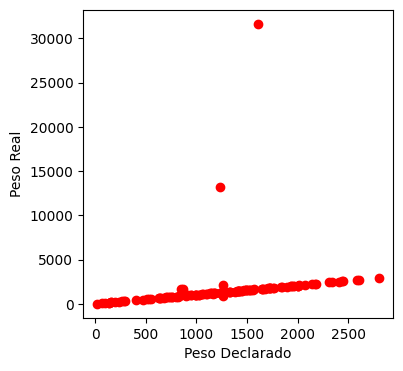

In [ ]:
xData = np.array(X)
yData = np.array(y)

f = plt.figure(figsize=(4, 4), dpi=100)
plt.plot(xData, yData,'ro')
plt.xlabel("Peso Declarado")
plt.ylabel("Peso Real")
plt.show()

Realize a previsão usando a regressão linear

In [ ]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)
print(y_pred)

[2098.02650819 1137.33278161 1997.98471195 1516.91977682 1050.80234047
 1756.22322636 2289.5487978  1741.34051297 1547.36186517 2188.23262016
 2534.99572998 2585.78271528 1424.54789628 2141.06267059 1842.68543217
 2152.32719358 1669.72206179 2520.49699729 1633.88688894 2015.68185603
 2244.87205354 1669.72206179 2046.58175789 1993.97421588 1850.80135643
 2587.71231796 1375.616935   1868.94242569 1669.72206179  969.10850231
 1177.42013185  950.66183061 1565.55243238 1887.36888938 1652.53597641
 1048.19037783 1813.12995608 2387.35488318 1565.91949319 1022.26807255
 1567.68349936 2033.26769955  987.31156638 1010.9185213  1972.72674192
 1156.18206207 1095.86820643 1947.78001331 2242.11982121 1335.73075756
 1638.17131914 1339.54982624 1670.4621529  1115.23118469  759.93814745
 1273.55378671 2604.34201364 2162.96937203 1537.38093041 1324.778144
 2247.89809922 1950.80841026 1375.70925906 1956.88028205 2763.64003795
 3129.2826768   785.77132273 2381.57388565 3139.28174545 3085.10450382
 2789.89

Apresente o coeficiente de determinação (R2)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
print("R²:", r2)

R²: 0.06548126284813538


Apresente o erro médio quadrático (MSE)

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

MSE: 8550688.583277848


Plotar a reta da regressão juntamente com os pontos X e y no gráfico de dispersão

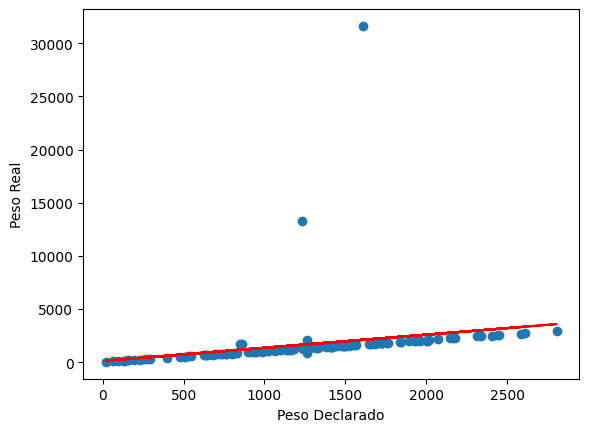

In [ ]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.xlabel("Peso Declarado")
plt.ylabel("Peso Real")
plt.show()

Faça a predição agora usando árvore de decisão, apresentando o coeficiente de determinação (R2) e o erro médio quadrático (MSE)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

modelo_arvore = DecisionTreeRegressor()
modelo_arvore.fit(X, y)
y_pred_arvore = modelo_arvore.predict(X)

r2 = r2_score(y, y_pred_arvore)
mse = mean_squared_error(y, y_pred_arvore)

print("R² (Árvore):", r2)
print("MSE (Árvore):", mse)

R² (Árvore): 0.999315628261744
MSE (Árvore): 6261.885798949062


Plotar a função da regressão da árvore de decisão juntamente com os pontos X e y no gráfico de dispersão

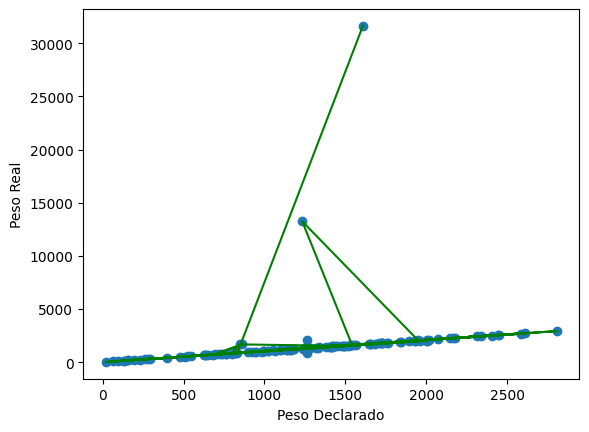

In [ ]:
plt.scatter(X, y)
plt.plot(X, y_pred_arvore, color='green')
plt.xlabel("Peso Declarado")
plt.ylabel("Peso Real")
plt.show()